In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import time
import re

In [2]:
url = "https://www.jumia.ug/laptops/"
headers = {"User-Agent": "Mozilla/5.0"}

In [44]:

def get_page(url):
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "lxml")
    return soup

pages=50
all_products = []

for page in range(1, pages+1):
    url = f"https://www.jumia.ug/laptops/?page={page}#catalog-listing"
    soup = get_page(url)
    products = soup.find_all("article", class_="prd _fb col c-prd")

    for product in products:
        name = product.find('h3', class_='name')
        name = name.text if name else None

        price = product.find('div', class_='prc')
        price = price.text if price else None

        old_price = product.find('div', class_='old')
        old_price = old_price.text if old_price else None

        discount = product.find('div', class_='bdg _dsct _sm')
        discount = discount.text if discount else None

        product_data = {'name':name, 'price':price, 'old_price':old_price, 'discount':discount}

        all_products.append(product_data)
    time.sleep(1)

df = pd.DataFrame(all_products)


In [62]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       2000 non-null   str  
 1   price      2000 non-null   str  
 2   old_price  1898 non-null   str  
 3   discount   1898 non-null   str  
 4   range      2000 non-null   bool 
dtypes: bool(1), str(4)
memory usage: 64.6 KB


,name,price,old_price,discount,range
0,Refurbished HP Probook 640 Core I5 8GB Ram 500...,"UGX 559,000","UGX 1,400,000",60%,False
1,Latitude 11'' Inch 3180/3190 4GB RAM 128GB SSD...,"UGX 349,000","UGX 700,000",50%,False
2,Hp Refurbished Probook TouchScreen X360 Intel ...,"UGX 440,000","UGX 980,019",55%,False
3,"11e Mini laptop,11.6"" Inch 4GB RAM,128GB SSD, ...","UGX 329,000","UGX 800,000",59%,False
4,"Travelmate 12 Inch Laptop 4GB RAM 128GB SSD, I...","UGX 356,400","UGX 800,000",55%,False


In [68]:
def data_cleaning(df):
    # Convert 'price' and 'discount' columns from boolean to string values
    df['price'] = df['price'].astype(str)
    df['discount'] = df['discount'].astype(str)

    # Removing data contains '-' from 'price' and 'discount' columns
    df = df[~df['price'].str.contains('-', na=False)]
    df = df[~df['discount'].str.contains('-', na=False)]
    
    # Removing 'UGX', ',' and '%' from 'price', 'old_price' and 'discount' columns
    df['price'] = df['price'].str.replace('UGX', '').str.replace(',', '').str.strip()
    df['old_price'] = df['old_price'].str.replace('UGX', '').str.replace(',', '').str.strip()
    
    # Convert 'price' and 'old_price' columns to numeric values
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['old_price'] = pd.to_numeric(df['old_price'], errors='coerce')
    return df

In [70]:
# Apply the data cleaning function to the new variable called data_jumia
data_jumia = data_cleaning(df)
data_jumia.head(20)

,name,price,old_price,discount,range
0,Refurbished HP Probook 640 Core I5 8GB Ram 500...,559000,1400000.0,60%,False
1,Latitude 11'' Inch 3180/3190 4GB RAM 128GB SSD...,349000,700000.0,50%,False
2,Hp Refurbished Probook TouchScreen X360 Intel ...,440000,980019.0,55%,False
3,"11e Mini laptop,11.6"" Inch 4GB RAM,128GB SSD, ...",329000,800000.0,59%,False
4,"Travelmate 12 Inch Laptop 4GB RAM 128GB SSD, I...",356400,800000.0,55%,False
5,"HP Certified Refurbished 14"" EliteBook 840 Cor...",563500,1100000.0,49%,False
6,"Elitebook 820(12.5-inch,Core I5,8GB RAM,500 GB...",579900,1320017.0,56%,False
7,"Renewed 12.5"" EliteBook 820,Core I5 8GB Ram,5...",540000,1390000.0,61%,False
8,Refurbished Surface Pro 7 Plus Laptop i5 11th ...,2550000,4000000.0,36%,False
9,Refurbished Surface Pro 7 Plus Laptop i5 11th ...,2650000,4500000.0,41%,False


<Axes: >

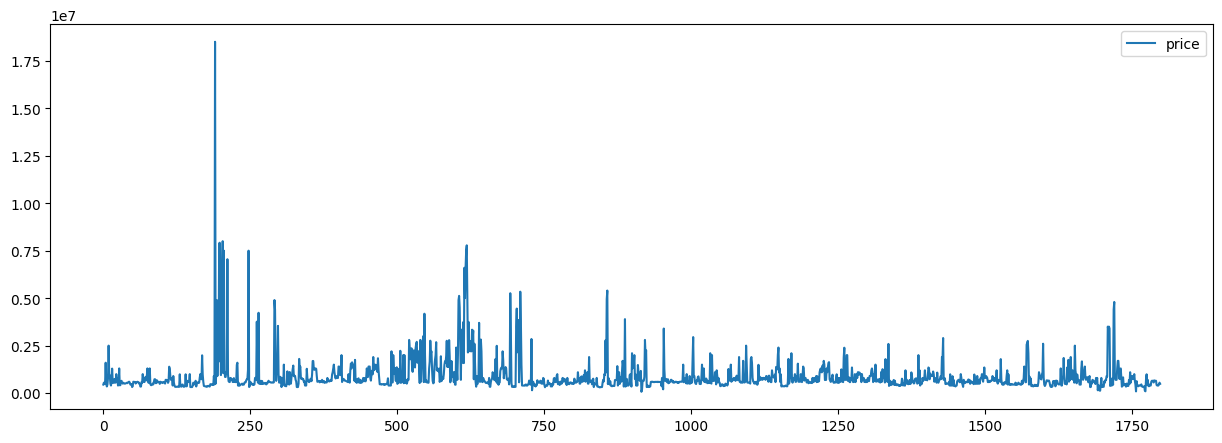

In [76]:
group_price = data_jumia.groupby('name')['price'].mean()
group_price.reset_index().plot(figsize=(15, 5))